# Deep Learning - Clasificación de Lesiones Cutáneas

**Autores:** David Moreda AmezcuaS , Javier Cerón Contreras, Pedro Martínez Huertas

**Máster en Inteligencia Artificial - Universidad Loyola**

## 1. Análisis Exploratorio del Dataset

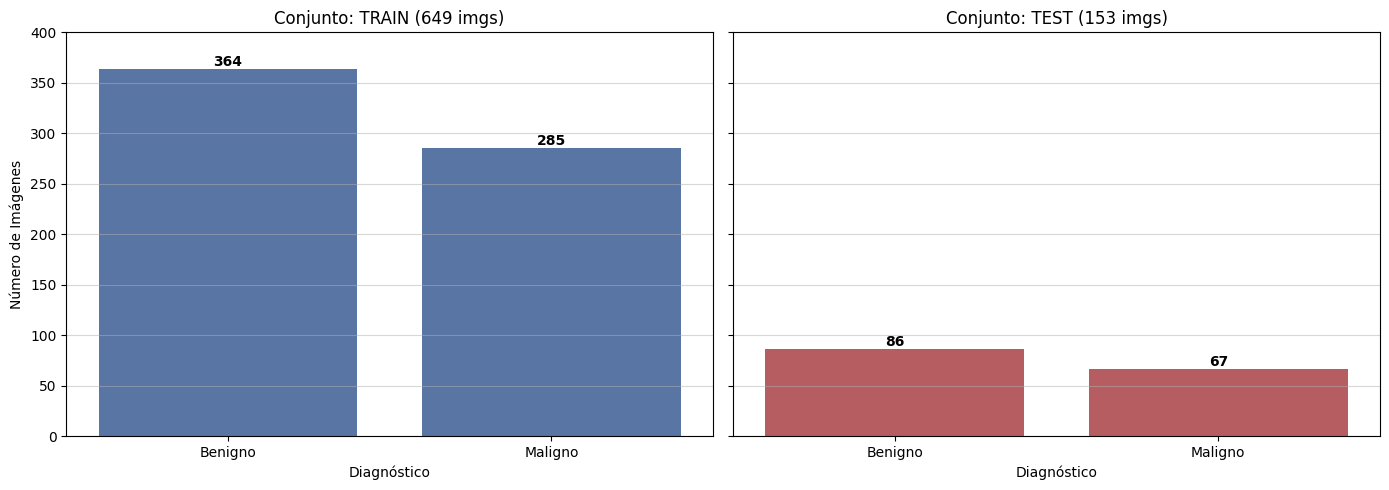


Resumen de Tamaños:
Medio: 890x890
Mínimo: 147x147
Máximo: 3474x3476


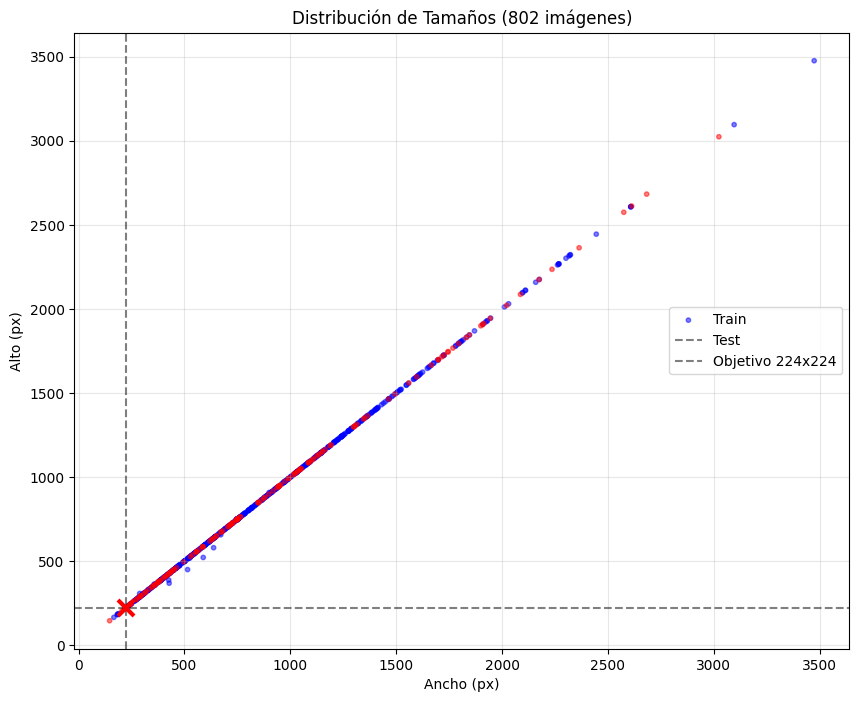

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
from tqdm import tqdm

RUTA_RAIZ = "../../Datos/images/SPLIT_BINARIO"
splits = ["train", "test"]
colores = ["#4c72b0", "#c44e52"]

# --- Distribución de clases ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for i, split in enumerate(splits):
    split_path = os.path.join(RUTA_RAIZ, split)
    clases = sorted(os.listdir(split_path))
    conteo = {c: len(os.listdir(os.path.join(split_path, c))) for c in clases}
    total = sum(conteo.values())

    sns.barplot(x=list(conteo.keys()), y=list(conteo.values()), ax=axes[i], color=colores[i])
    axes[i].set_title(f"Conjunto: {split.upper()} ({total} imgs)")
    axes[i].set_xlabel("Diagnóstico")
    axes[i].grid(axis="y", alpha=0.5)
    axes[i].set_ylim(0, 400) 

    for idx, (clase, valor) in enumerate(conteo.items()):
        axes[i].text(idx, valor + 3, str(valor), ha="center", fontweight="bold")

axes[0].set_ylabel("Número de Imágenes")
plt.tight_layout()
plt.show()

# --- Tamaño de imágenes ---
anchos = []
altos = []
colores_puntos = []
mapa_colores = {"train": "blue", "test": "red"}

for split in splits:
    split_path = os.path.join(RUTA_RAIZ, split)
    clases = sorted(os.listdir(split_path))
    for clase in clases:
        clase_path = os.path.join(split_path, clase)
        archivos = [f for f in os.listdir(clase_path) if f.lower().endswith((".png", ".jpg", ".jpeg"))]
        for nombre in tqdm(archivos, desc=f"{split}/{clase}", leave=False):
            ruta_completa = os.path.join(clase_path, nombre)
            with Image.open(ruta_completa) as img:
                w, h = img.size
                anchos.append(w)
                altos.append(h)
                colores_puntos.append(mapa_colores[split])

plt.figure(figsize=(10, 8))
plt.scatter(anchos, altos, c=colores_puntos, alpha=0.5, s=10)
plt.axvline(224, color="k", linestyle="--", alpha=0.5)
plt.axhline(224, color="k", linestyle="--", alpha=0.5)
plt.plot(224, 224, "rx", markersize=12, markeredgewidth=3)
plt.title(f"Distribución de Tamaños ({len(anchos)} imágenes)")
plt.xlabel("Ancho (px)")
plt.ylabel("Alto (px)")
plt.legend(["Train", "Test", "Objetivo 224x224"])
plt.grid(True, alpha=0.3)

print(f"\nResumen de Tamaños:")
print(f"Medio: {sum(anchos)//len(anchos)}x{sum(altos)//len(altos)}")
print(f"Mínimo: {min(anchos)}x{min(altos)}")
print(f"Máximo: {max(anchos)}x{max(altos)}")

plt.show()


### Conclusiones del EDA

**Dataset:**
- MEL (Melanoma) es la clase minoritaria, será la más difícil de clasificar
- Train: 500 imgs, Validation: 130 imgs, Test: 161 imgs
- Dataset pequeño → necesitamos Data Augmentation

**Tamaños:**
- Todas las imágenes tienen proporción similar
- Podemos usar resize directo a 224x224

## 3. Hiperparametrización con optuna

📊 VISUALIZACIÓN DE HIPERPARAMETRIZACIÓN - TODOS LOS MODELOS

🔍 Cargando estudios de Optuna...
  ✅ ResNet18: 20 trials
  ✅ DenseNet121: 20 trials
  ✅ YOLO26x: 20 trials

📈 Generando gráfica: Evolución de scores...



🎨 Generando gráficas: Combinaciones de hiperparámetros...


  ✅ ResNet18


  ✅ DenseNet121


  ✅ YOLO26x

📊 ESTADÍSTICAS DE TRIALS

     Modelo  Total Trials  Completados  Podados  Fallidos % Completados
   ResNet18            20            9       11         0         45.0%
DenseNet121            20           12        8         0         60.0%
    YOLO26x            20           11        9         0         55.0%

🏆 MEJORES HIPERPARÁMETROS POR MODELO

────────────────────────────────────────────────────────────────────────────────
📌 RESNET18
────────────────────────────────────────────────────────────────────────────────
🏆 Mejor Score: 0.7551
🔢 Mejor Trial: #15

📝 Hiperparámetros:
   • batch_size          : 32
   • dropout             : 0.000000
   • lr_backbone         : 0.000918
   • lr_head             : 0.000124
   • weight_decay        : 0.000630

────────────────────────────────────────────────────────────────────────────────
📌 DENSENET121
────────────────────────────────────────────────────────────────────────────────
🏆 Mejor Score: 0.7592
🔢 Mejor Trial: #8

📝 Hiperp

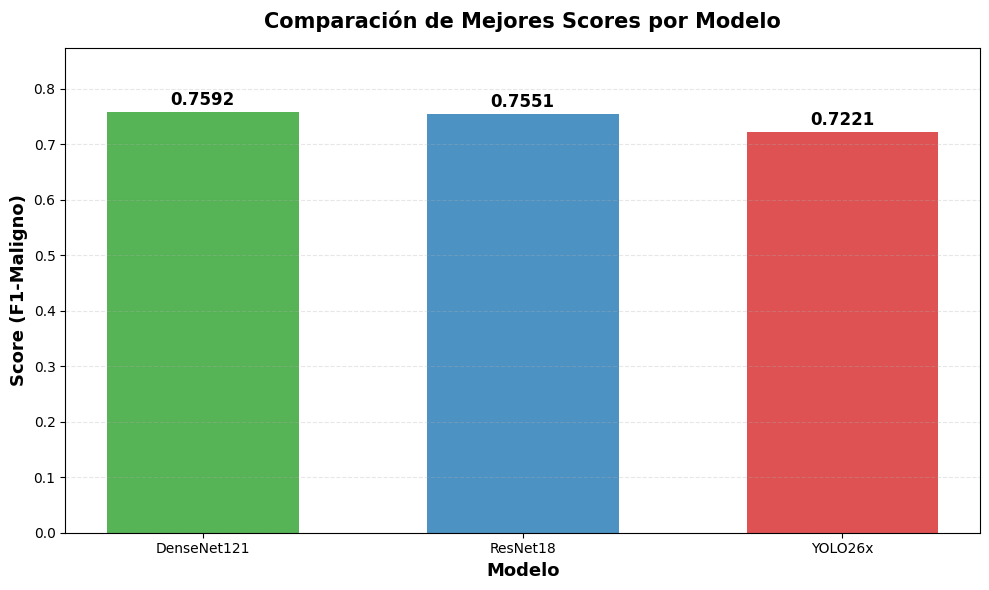


✅ VISUALIZACIÓN COMPLETADA



In [3]:
"""
Visualización de hiperparametrización - ResNet18, DenseNet121, YOLO26x
"""

import optuna
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Configuración
DB_RESNET_DENSENET_YOLO = "hyperparameters/binary_tuning_f1.db"

print("="*80)
print("📊 VISUALIZACIÓN DE HIPERPARAMETRIZACIÓN - TODOS LOS MODELOS")
print("="*80)

# ============================================================================
# 1. CARGAR ESTUDIOS
# ============================================================================

print("\n🔍 Cargando estudios de Optuna...")

storage_res_dense_yolo = f"sqlite:///{DB_RESNET_DENSENET_YOLO}"
try:
    study_resnet = optuna.load_study(study_name="resnet18_binary_f1", storage=storage_res_dense_yolo)
    print(f"  ✅ ResNet18: {len(study_resnet.trials)} trials")
except:
    print(f"  ❌ ResNet18 no encontrado")
    study_resnet = None

try:
    study_densenet = optuna.load_study(study_name="densenet121_binary_f1", storage=storage_res_dense_yolo)
    print(f"  ✅ DenseNet121: {len(study_densenet.trials)} trials")
except:
    print(f"  ❌ DenseNet121 no encontrado")
    study_densenet = None

try:
    study_yolo = optuna.load_study(study_name="yolo_binary_f1", storage=storage_res_dense_yolo)
    print(f"  ✅ YOLO26x: {len(study_yolo.trials)} trials")
except:
    print(f"  ❌ YOLO26x no encontrado")
    study_yolo = None

def get_completed_trials(study):
    if study is None:
        return []
    return [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]

# ============================================================================
# 2. GRÁFICA: EVOLUCIÓN DE SCORES
# ============================================================================

print("\n📈 Generando gráfica: Evolución de scores...")

studies = {
    'ResNet18': study_resnet,
    'DenseNet121': study_densenet,
    'YOLO26x': study_yolo
}

colors = {'ResNet18': '#1f77b4', 'DenseNet121': '#2ca02c', 'YOLO26x': '#d62728'}

fig = go.Figure()

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    if not completed:
        continue
    
    trial_numbers = [t.number for t in completed]
    scores = [t.value for t in completed]
    
    # Trials
    fig.add_trace(go.Scatter(
        x=trial_numbers, y=scores,
        mode='markers+lines',
        name=f'{model_name}',
        marker=dict(size=8, color=colors[model_name]),
        line=dict(color=colors[model_name], width=2, dash='dot'),
        opacity=0.6
    ))
    
    # Best so far
    best_so_far = []
    current_best = -float('inf')
    for score in scores:
        current_best = max(current_best, score)
        best_so_far.append(current_best)
    
    fig.add_trace(go.Scatter(
        x=trial_numbers, y=best_so_far,
        mode='lines',
        name=f'{model_name} (best)',
        line=dict(color=colors[model_name], width=3),
        opacity=0.9
    ))

fig.update_layout(
    title='Evolución de Scores en Hiperparametrización',
    xaxis_title='Trial Number',
    yaxis_title='Score (F1- Maligno)',
    hovermode='closest',
    template='plotly_white',
    height=600,
    font=dict(size=12)
)
fig.show()

# ============================================================================
# 3. GRÁFICAS: PARALLEL COORDINATES (Combinaciones de hiperparámetros)
# ============================================================================

print("\n🎨 Generando gráficas: Combinaciones de hiperparámetros...")

for model_name, study in studies.items():
    if study is None or len(get_completed_trials(study)) < 3:
        continue
    
    try:
        fig = optuna.visualization.plot_parallel_coordinate(study)
        fig.update_layout(
            title=f'Combinaciones de Hiperparámetros - {model_name}',
            height=500
        )
        fig.show()
        print(f"  ✅ {model_name}")
    except Exception as e:
        print(f"  ⚠️  Error en {model_name}: {e}")

# ============================================================================
# 4. TABLA: ESTADÍSTICAS DE TRIALS
# ============================================================================

print("\n" + "="*80)
print("📊 ESTADÍSTICAS DE TRIALS")
print("="*80)

stats_data = []

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    total = len(study.trials)
    pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
    failed = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.FAIL)
    
    stats_data.append({
        'Modelo': model_name,
        'Total Trials': total,
        'Completados': len(completed),
        'Podados': pruned,
        'Fallidos': failed,
        '% Completados': f"{len(completed)/total*100:.1f}%"
    })

df_stats = pd.DataFrame(stats_data)
print("\n" + df_stats.to_string(index=False))

# ============================================================================
# 5. RESUMEN: MEJORES HIPERPARÁMETROS
# ============================================================================

print("\n" + "="*80)
print("🏆 MEJORES HIPERPARÁMETROS POR MODELO")
print("="*80)

results_summary = []

for model_name, study in studies.items():
    if study is None:
        continue
    
    completed = get_completed_trials(study)
    if not completed:
        continue
    
    best_trial = study.best_trial
    
    print(f"\n{'─'*80}")
    print(f"📌 {model_name.upper()}")
    print(f"{'─'*80}")
    print(f"🏆 Mejor Score: {best_trial.value:.4f}")
    print(f"🔢 Mejor Trial: #{best_trial.number}")
    print(f"\n📝 Hiperparámetros:")
    
    for param, value in sorted(best_trial.params.items()):
        if isinstance(value, float):
            print(f"   • {param:20s}: {value:.6f}")
        else:
            print(f"   • {param:20s}: {value}")
    
    results_summary.append({
        'Modelo': model_name,
        'Score': best_trial.value
    })

# ============================================================================
# 6. GRÁFICA: COMPARACIÓN DE SCORES (MATPLOTLIB)
# ============================================================================

if results_summary:
    print("\n" + "="*80)
    print("📊 COMPARACIÓN FINAL")
    print("="*80)
    
    df = pd.DataFrame(results_summary).sort_values('Score', ascending=False)
    print("\n" + df.to_string(index=False))
    
    # Gráfica con matplotlib
    fig, ax = plt.subplots(figsize=(10, 6))
    
    bar_colors = [colors.get(m, 'gray') for m in df['Modelo']]
    bars = ax.bar(df['Modelo'], df['Score'], color=bar_colors, alpha=0.8, width=0.6)
    
    # Valores encima de barras
    for bar, score in zip(bars, df['Score']):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{score:.4f}',
                ha='center', va='bottom', fontweight='bold', fontsize=12)
    
    ax.set_ylabel('Score (F1-Maligno)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Modelo', fontsize=13, fontweight='bold')
    ax.set_title('Comparación de Mejores Scores por Modelo', fontsize=15, fontweight='bold', pad=15)
    ax.set_ylim(0, max(df['Score']) * 1.15)
    ax.grid(True, alpha=0.3, axis='y', linestyle='--')
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("✅ VISUALIZACIÓN COMPLETADA")
print("="*80 + "\n")

## 4. Carga de Datos y Data Augmentation

In [2]:
import torch
from torchvision import datasets
from torch.utils.data import DataLoader, Dataset
from ultralytics.data.augment import classify_augmentations, classify_transforms
from sklearn.model_selection import StratifiedKFold
import random
import numpy as np

# --- 1. Configuración y Reproductibilidad ---
SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

RUTA_BASE = "../../Datos/images/SPLIT_BINARIO"
IMG_SIZE = 224
K_FOLDS = 5
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

# Definimos los Batch Sizes específicos por modelo
BATCH_SIZES = {
    "resnet18": 32,
    "densenet121": 16
}

# --- 2. Pipelines de Transformación ---
train_pipeline = classify_augmentations(
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    scale=(0.5, 1.0),
    hflip=0.5,
    vflip=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    erasing=0.3,
)

val_test_pipeline = classify_transforms(
    size=IMG_SIZE,
    mean=MEAN,
    std=STD,
    interpolation="BILINEAR"
)

# --- 3. Dataset Base ---
# Carga inicial para obtener rutas y etiquetas (sin transform aún)
full_train_dataset = datasets.ImageFolder(f"{RUTA_BASE}/train", transform=None)
targets = full_train_dataset.targets
classes = full_train_dataset.classes
print(f"Train total: {len(full_train_dataset)} imgs, Clases: {classes}")

# --- 4. Wrapper para Transformaciones Dinámicas ---
class SubsetConTransform(Dataset):
    def __init__(self, dataset, indices, transform):
        self.dataset = dataset
        self.indices = list(indices)
        self.transform = transform

    def __getitem__(self, idx):
        # Obtenemos la imagen original y targets del dataset padre
        img, label = self.dataset[self.indices[idx]]
        # Aplicamos la transformación específica (train o val)
        if self.transform is not None:
            img = self.transform(img)
        return img, label

    def __len__(self):
        return len(self.indices)

# --- 5. Pre-cálculo de Folds ---
skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
# Convertimos a lista para "congelar" los índices y reusarlos en cada modelo
FOLDS_INDICES = list(skf.split(range(len(targets)), targets))

# --- 6. Funciones Generadoras de DataLoaders ---

def get_fold_loaders(fold_idx, batch_size):
    """
    Crea train_loader y val_loader para un fold específico y un batch_size dado.
    """
    train_idx, val_idx = FOLDS_INDICES[fold_idx]
    
    # Creamos Subsets con sus transformaciones correspondientes
    train_subset = SubsetConTransform(full_train_dataset, train_idx, train_pipeline)
    val_subset = SubsetConTransform(full_train_dataset, val_idx, val_test_pipeline)
    
    train_loader = DataLoader(
        train_subset,
        batch_size=batch_size,
        shuffle=True,      # Importante shuffle en train
        num_workers=4,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_subset,
        batch_size=batch_size,
        shuffle=False,     # No shuffle en val
        num_workers=4,
        pin_memory=True
    )
    
    return train_loader, val_loader

def get_test_loader(batch_size):
    """Genera el loader de test"""
    test_ds = datasets.ImageFolder(f"{RUTA_BASE}/test", transform=val_test_pipeline)
    return DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print("\n✅ Funciones de carga de datos preparadas.")
print(f"  - get_fold_loaders(fold_idx, batch_size) -> train_loader, val_loader")
print(f"  - get_test_loader(batch_size) -> test_loader")

Train total: 649 imgs, Clases: ['Benigno', 'Maligno']

✅ Funciones de carga de datos preparadas.
  - get_fold_loaders(fold_idx, batch_size) -> train_loader, val_loader
  - get_test_loader(batch_size) -> test_loader


### Visualización del Data Augmentation

Visualizando Augmentation para clases: ['Benigno', 'Maligno']


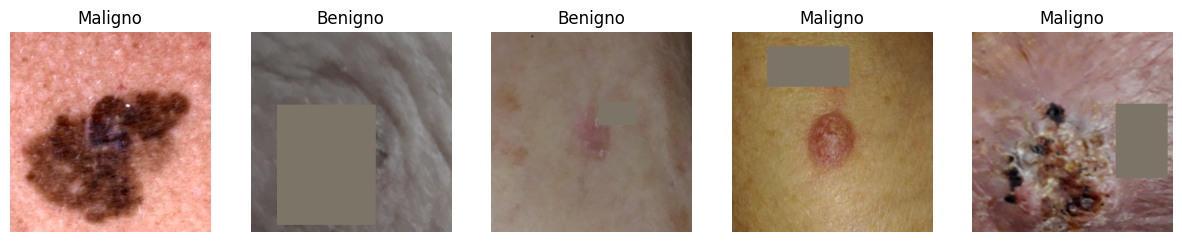

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# 1. Dataset Temporal para Visualización
# Usamos el train_pipeline que definimos antes (con augmentations)
viz_dataset = datasets.ImageFolder(f"{RUTA_BASE}/train", transform=train_pipeline)

# 2. Loader pequeño (batch=5 es suficiente para ver 5 ejemplos)
viz_loader = DataLoader(viz_dataset, batch_size=5, shuffle=True)

# 3. Obtener un batch
imgs, labels = next(iter(viz_loader))

# 4. Función para des-normalizar y pintar
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    # PyTorch es (C, H, W), Matplotlib quiere (H, W, C)
    img = tensor.permute(1, 2, 0).numpy()
    # Deshacer (val - mean) / std  =>  val = img * std + mean
    return np.clip(img * std + mean, 0, 1)

print(f"Visualizando Augmentation para clases: {viz_dataset.classes}")

plt.figure(figsize=(15, 5))
for i in range(5):
    ax = plt.subplot(1, 5, i+1)
    plt.imshow(denormalize(imgs[i]))
    # Usamos las clases del viz_dataset (Benigno/Maligno)
    plt.title(viz_dataset.classes[labels[i]])
    plt.axis("off")
plt.show()

# 5. Limpieza
del viz_dataset, viz_loader

## 3. Funciones de Entrenamiento y Evaluación

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import copy
import torch
import torch.nn as nn
import pandas as pd
from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
    accuracy_score, cohen_kappa_score, precision_score, recall_score
)

# ============================================================
# 1. FUNCIONES AUXILIARES DE MÉTRICAS
# ============================================================

def obtener_predicciones(model, loader, device):
    """Obtiene predicciones, etiquetas reales y probabilidades."""
    model.eval()
    y_true, y_pred, y_probs = [], [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())
    return np.array(y_true), np.array(y_pred), np.array(y_probs)

def calcular_metricas(y_true, y_pred):
    """Calcula todas las métricas clave."""
    return {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'kappa': cohen_kappa_score(y_true, y_pred),
    }

def mostrar_reporte_completo(y_true, y_pred, classes, titulo):
    """Muestra matriz de confusión y reporte detallado."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Matriz de Confusión - {titulo}')
    plt.ylabel('Real')
    plt.xlabel('Predicción')
    plt.show()

    metricas = calcular_metricas(y_true, y_pred)
    print(f"\n{'='*60}\nREPORTE: {titulo}\n{'='*60}")
    print(classification_report(y_true, y_pred, target_names=classes, zero_division=0))
    print(f"{'─'*60}")
    print(f"  Accuracy:           {metricas['accuracy']:.4f}")
    print(f"  F1 Macro:           {metricas['f1_macro']:.4f}")
    print(f"  Recall Macro:       {metricas['recall_macro']:.4f}")
    print(f"  Cohen's Kappa:      {metricas['kappa']:.4f}")
    print(f"{'='*60}")
    return metricas

# ============================================================
# 2. FUNCIONES DE VISUALIZACIÓN (HISTORIAL)
# ============================================================

def plot_training_history(historial, titulo=""):
    epochs = range(1, len(historial['train_loss']) + 1)
    plt.figure(figsize=(15, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, historial['train_loss'], label='Train Loss', color='blue')
    plt.plot(epochs, historial['val_loss'], label='Val Loss', color='orange', linestyle='--')
    plt.title(f'Loss - {titulo}')
    plt.xlabel('Épocas'); plt.ylabel('Loss'); plt.legend(); plt.grid(True, alpha=0.3)

    # F1
    plt.subplot(1, 2, 2)
    plt.plot(epochs, historial['val_f1'], label='Val F1 (Macro)', color='green', marker='o')
    plt.axhline(y=max(historial['val_f1']), color='r', linestyle=':', label=f'Best: {max(historial["val_f1"]):.4f}')
    plt.title(f'F1-Score - {titulo}')
    plt.xlabel('Épocas'); plt.ylabel('F1'); plt.legend(); plt.grid(True, alpha=0.3)
    
    plt.tight_layout(); plt.show()

def plot_kfold_history(historiales, nombre_exp):
    """Promedia las curvas de los 5 folds."""
    max_epochs = max(len(h['train_loss']) for h in historiales)
    def pad(lst, length): return lst + [lst[-1]] * (length - len(lst))

    # Convertir a arrays (N_folds, N_epochs)
    train_losses = np.array([pad(h['train_loss'], max_epochs) for h in historiales])
    val_losses = np.array([pad(h['val_loss'], max_epochs) for h in historiales])
    val_f1s = np.array([pad(h['val_f1'], max_epochs) for h in historiales])

    epochs = range(1, max_epochs + 1)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Loss Plot
    ax = axes[0]
    mean_tl, std_tl = train_losses.mean(0), train_losses.std(0)
    mean_vl, std_vl = val_losses.mean(0), val_losses.std(0)
    ax.plot(epochs, mean_tl, 'b-', label='Train Loss (avg)')
    ax.fill_between(epochs, mean_tl-std_tl, mean_tl+std_tl, alpha=0.2, color='blue')
    ax.plot(epochs, mean_vl, 'r--', label='Val Loss (avg)')
    ax.fill_between(epochs, mean_vl-std_vl, mean_vl+std_vl, alpha=0.2, color='red')
    ax.set_title(f'Loss Promedio - {nombre_exp}'); ax.legend(); ax.grid(True, alpha=0.3)

    # F1 Plot
    ax = axes[1]
    mean_f1, std_f1 = val_f1s.mean(0), val_f1s.std(0)
    ax.plot(epochs, mean_f1, 'g-', label='Val F1 Macro (avg)')
    ax.fill_between(epochs, mean_f1-std_f1, mean_f1+std_f1, alpha=0.2, color='green')
    ax.set_title(f'F1 Promedio - {nombre_exp}'); ax.legend(); ax.grid(True, alpha=0.3)
    
    plt.tight_layout(); plt.show()

# ============================================================
# 3. BUCLE DE ENTRENAMIENTO (UN FOLD)
# ============================================================

def entrenar_un_fold(model, train_loader, val_loader, criterion, optimizer, device, epochs, nombre_archivo):
    historial = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    best_f1 = 0.0
    best_wts = copy.deepcopy(model.state_dict())

    for epoch in range(epochs):
        # Train
        model.train()
        r_loss = 0.0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            r_loss += loss.item() * x.size(0)
        
        train_loss = r_loss / len(train_loader.dataset)

        # Val
        model.eval()
        v_loss = 0.0; y_true = []; y_pred = []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                v_loss += loss.item() * x.size(0)
                _, preds = torch.max(out, 1)
                y_true.extend(y.cpu().numpy()); y_pred.extend(preds.cpu().numpy())

        val_loss = v_loss / len(val_loader.dataset)
        val_f1 = f1_score(y_true, y_pred, average='macro')

        historial['train_loss'].append(train_loss)
        historial['val_loss'].append(val_loss)
        historial['val_f1'].append(val_f1)

        msg = ""
        if val_f1 > best_f1:
            best_f1 = val_f1
            best_wts = copy.deepcopy(model.state_dict())
            torch.save(model.state_dict(), nombre_archivo)
            msg = "⚡ Mejor!"
        
        print(f"  Ep {epoch+1:02d} | T.Loss: {train_loss:.4f} | V.Loss: {val_loss:.4f} | V.F1: {val_f1:.4f} {msg}")

    model.load_state_dict(best_wts)
    return model, historial

# ============================================================
# 4. PIPELINE PRINCIPAL (LANZAR EXPERIMENTO)
# ============================================================

def lanzar_experimento_kfold(crear_modelo_fn, nombre_exp, device, batch_size, epochs=25):
    """
    Versión corregida: Prioriza F1-MACRO.
    """
    print(f"\n{'='*70}\n🚀 EXPERIMENTO 5-FOLD: {nombre_exp} (Batch Size: {batch_size})\n{'='*70}")
    
    num_classes = len(classes)
    metricas_folds = []
    historiales = []
    modelos_state_dicts = []

    # --- 1. ENTRENAMIENTO CRUZADO ---
    for fold_idx in range(K_FOLDS):
        print(f"\n🔹 FOLD {fold_idx+1}/{K_FOLDS}")
        
        train_loader, val_loader = get_fold_loaders(fold_idx, batch_size)
        
        # Pesos de clase
        train_indices = FOLDS_INDICES[fold_idx][0]
        fold_targets = [targets[i] for i in train_indices]
        counts = np.bincount(fold_targets, minlength=num_classes).astype(float)
        weights = 1.0 / counts
        weights = weights / weights.sum() * num_classes
        class_weights = torch.FloatTensor(weights).to(device)
        
        criterion = nn.CrossEntropyLoss(weight=class_weights)
        model, optimizer = crear_modelo_fn(num_classes, device)

        filename = f"{nombre_exp}_fold{fold_idx+1}.pth"
        model, hist = entrenar_un_fold(model, train_loader, val_loader, criterion, optimizer, device, epochs, filename)
        
        # Métricas Validación
        yt, yp, _ = obtener_predicciones(model, val_loader, device)
        mets = calcular_metricas(yt, yp)
        
        # Usamos F1 MACRO
        print(f"   🏁 Fin Fold {fold_idx+1}: F1(Macro)={mets['f1_macro']:.4f}")
        
        metricas_folds.append(mets)
        historiales.append(hist)
        modelos_state_dicts.append(copy.deepcopy(model.state_dict()))

    # --- 2. RESUMEN VALIDACIÓN ---
    print(f"\n{'='*70}\n📊 RESUMEN VALIDACIÓN (CV)\n{'='*70}")
    df = pd.DataFrame(metricas_folds, index=[f"Fold {i+1}" for i in range(K_FOLDS)])
    df.loc['Media'] = df.mean()
    df.loc['Std'] = df.std()
    # Mostramos métricas genéricas
    print(df[['f1_macro', 'accuracy', 'kappa']].round(4).to_string())

    print("\n📈 Curvas Promedio:")
    plot_kfold_history(historiales, nombre_exp)

    # --- 3. EVALUACIÓN INDIVIDUAL EN TEST ---
    print(f"\n{'='*70}\n🧪 TEST DETALLADO: MODELOS INDIVIDUALES\n{'='*70}")
    
    test_loader = get_test_loader(batch_size)
    testing_labels = []
    for _, y in test_loader: testing_labels.extend(y.numpy())
    
    test_individual_metrics = []
    
    for i, state in enumerate(modelos_state_dicts):
        print(f"  > Evaluando Modelo Fold {i+1} en Test...", end=" ")
        m, _ = crear_modelo_fn(num_classes, device)
        m.load_state_dict(state)
        
        _, y_pred_test, _ = obtener_predicciones(m, test_loader, device)
        
        mets = calcular_metricas(testing_labels, y_pred_test)
        print(f"F1(Macro)={mets['f1_macro']:.4f}")
        
        mets['Fold_Origen'] = f"Model_Fold_{i+1}"
        test_individual_metrics.append(mets)

    df_test_ind = pd.DataFrame(test_individual_metrics).set_index("Fold_Origen")
    print(df_test_ind[['f1_macro', 'accuracy', 'kappa']].round(4).to_string())

    # --- 4. EVALUACIÓN ENSEMBLE EN TEST ---
    print(f"\n{'='*70}\n🧩 EVALUACIÓN ENSEMBLE (Promedio de Probabilidades)\n{'='*70}")
    
    all_probs = []
    for state in modelos_state_dicts:
        m, _ = crear_modelo_fn(num_classes, device)
        m.load_state_dict(state)
        _, _, probs = obtener_predicciones(m, test_loader, device)
        all_probs.append(probs)
    
    avg_probs = np.mean(all_probs, axis=0)
    final_preds = np.argmax(avg_probs, axis=1)
    
    test_metrics_ensemble = mostrar_reporte_completo(testing_labels, final_preds, classes, f"TEST - Ensemble {nombre_exp}")
    
    # Comparar (f1_macro)
    best_ind_idx = np.argmax([m['f1_macro'] for m in test_individual_metrics])
    
    print(f"\n💡 CONCLUSIÓN:")
    print(f"   Mejor Individual (Fold {best_ind_idx+1}) F1(Macro): {test_individual_metrics[best_ind_idx]['f1_macro']:.4f}")
    print(f"   Ensemble Completo F1(Macro): {test_metrics_ensemble['f1_macro']:.4f}")
    
    return {
        'metricas_folds': df,
        'modelos': modelos_state_dicts,
        'test_metrics_individual': df_test_ind,
        'test_metrics_ensemble': test_metrics_ensemble
    }

print("✅ Funciones de Entrenamiento Multiclase adaptadas a Binario correctamente.")

✅ Funciones de Entrenamiento Multiclase adaptadas a Binario correctamente.


## 4. Modelo 1: ResNet-18

ResNet utiliza conexiones residuales (skip connections) que permiten entrenar redes profundas sin degradación del gradiente.

In [13]:
def crear_resnet18(num_classes, device):
    # 1. Cargar pesos pre-entrenados
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # 2. Congelar todo el backbone
    for param in model.parameters():
        param.requires_grad = False

    # 3. Descongelar último bloque (Layer 4)
    for param in model.layer4.parameters():
        param.requires_grad = True

    # 4. Nueva cabeza de clasificación binaria
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, num_classes)
    )

    model = model.to(device)

    # 5. Optimizador con Learning Rates diferenciales
    # (Usamos los valores que tenía tu código, pero idealmente vendrían del tuning)
    optimizer = optim.AdamW([
        {'params': model.layer4.parameters(), 'lr': 0.000918},
        {'params': model.fc.parameters(), 'lr': 0.000124}
    ], weight_decay=0.000630)
    
    return model, optimizer

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

import torchvision.models as models
import torch.optim as optim

Usando device: cuda


Usando device: cuda

🚀 EXPERIMENTO 5-FOLD: ResNet18_Binario_5Fold (Batch Size: 32)

🔹 FOLD 1/5
  Ep 01 | T.Loss: 1.0162 | V.Loss: 0.9312 | V.F1: 0.7304 ⚡ Mejor!
  Ep 02 | T.Loss: 0.6553 | V.Loss: 0.5254 | V.F1: 0.7608 ⚡ Mejor!
  Ep 03 | T.Loss: 0.5535 | V.Loss: 0.5292 | V.F1: 0.7140 
  Ep 04 | T.Loss: 0.4899 | V.Loss: 0.5310 | V.F1: 0.7842 ⚡ Mejor!
  Ep 05 | T.Loss: 0.4637 | V.Loss: 0.5214 | V.F1: 0.7364 
  Ep 06 | T.Loss: 0.4437 | V.Loss: 0.6162 | V.F1: 0.7768 
  Ep 07 | T.Loss: 0.4088 | V.Loss: 0.6091 | V.F1: 0.7382 
  Ep 08 | T.Loss: 0.4162 | V.Loss: 0.6021 | V.F1: 0.7062 
  Ep 09 | T.Loss: 0.4064 | V.Loss: 0.5700 | V.F1: 0.7684 
  Ep 10 | T.Loss: 0.4315 | V.Loss: 0.5862 | V.F1: 0.7690 
  Ep 11 | T.Loss: 0.3502 | V.Loss: 0.6696 | V.F1: 0.7615 
  Ep 12 | T.Loss: 0.3804 | V.Loss: 0.6706 | V.F1: 0.7045 
  Ep 13 | T.Loss: 0.3494 | V.Loss: 0.5513 | V.F1: 0.7454 
  Ep 14 | T.Loss: 0.3689 | V.Loss: 0.5710 | V.F1: 0.7536 
  Ep 15 | T.Loss: 0.3611 | V.Loss: 0.5962 | V.F1: 0.7454 
   🏁 Fin Fo

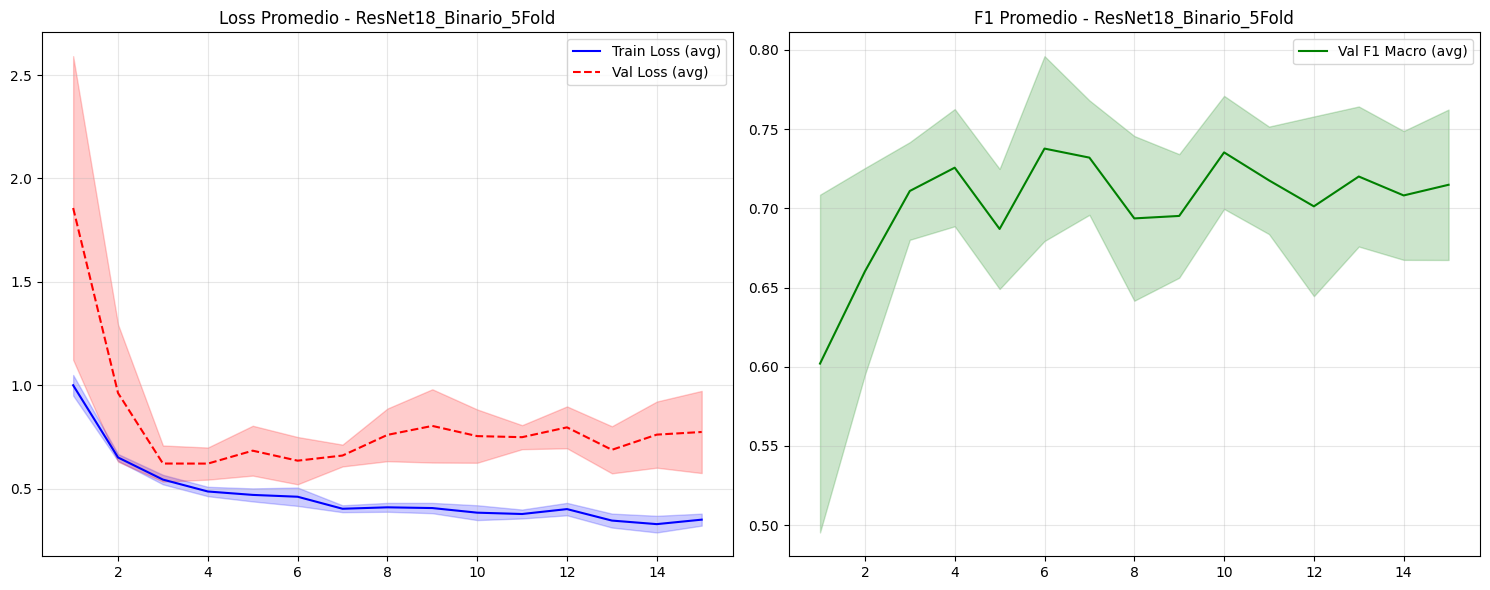


🧪 TEST DETALLADO: MODELOS INDIVIDUALES
  > Evaluando Modelo Fold 1 en Test... F1(Macro)=0.6803
  > Evaluando Modelo Fold 2 en Test... F1(Macro)=0.6993
  > Evaluando Modelo Fold 3 en Test... F1(Macro)=0.6536
  > Evaluando Modelo Fold 4 en Test... F1(Macro)=0.7121
  > Evaluando Modelo Fold 5 en Test... F1(Macro)=0.7283
              f1_macro  accuracy   kappa
Fold_Origen                             
Model_Fold_1    0.6803    0.6863  0.3606
Model_Fold_2    0.6993    0.6993  0.4088
Model_Fold_3    0.6536    0.6797  0.3238
Model_Fold_4    0.7121    0.7124  0.4290
Model_Fold_5    0.7283    0.7320  0.4566

🧩 EVALUACIÓN ENSEMBLE (Promedio de Probabilidades)


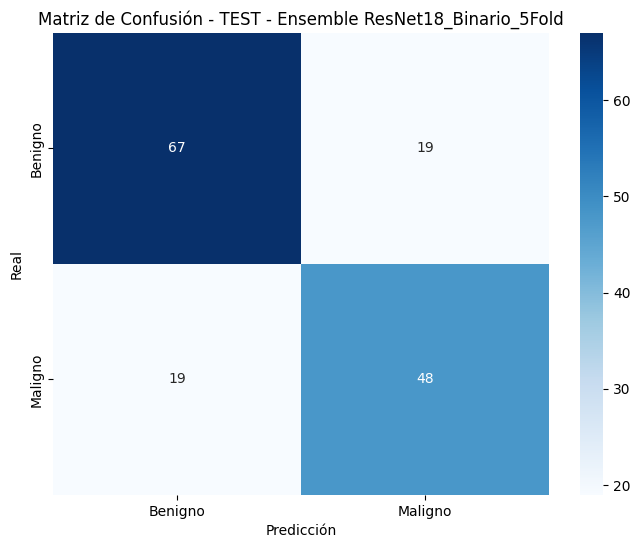


REPORTE: TEST - Ensemble ResNet18_Binario_5Fold
              precision    recall  f1-score   support

     Benigno       0.78      0.78      0.78        86
     Maligno       0.72      0.72      0.72        67

    accuracy                           0.75       153
   macro avg       0.75      0.75      0.75       153
weighted avg       0.75      0.75      0.75       153

────────────────────────────────────────────────────────────
  Accuracy:           0.7516
  F1 Macro:           0.7477
  Recall Macro:       0.7477
  Cohen's Kappa:      0.4955

💡 CONCLUSIÓN:
   Mejor Individual (Fold 5) F1(Macro): 0.7283
   Ensemble Completo F1(Macro): 0.7477


In [12]:
import torchvision.models as models
import torch.optim as optim

# Configuramos el dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

# --- Definición de la factoría del modelo ---
# Esta función se llamará al inicio de cada Fold para crear un modelo limpio
def crear_resnet18(num_classes, device):
    # 1. Cargar pesos pre-entrenados
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # 2. Congelar todo el backbone
    for param in model.parameters():
        param.requires_grad = False

    # 3. Descongelar último bloque (Layer 4)
    for param in model.layer4.parameters():
        param.requires_grad = True

    # 4. Nueva cabeza de clasificación binaria
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(num_ftrs, num_classes)
    )

    model = model.to(device)

    # 5. Optimizador con Learning Rates diferenciales
    # (Usamos los valores que tenía tu código, pero idealmente vendrían del tuning)
    optimizer = optim.AdamW([
        {'params': model.layer4.parameters(), 'lr': 0.000918},
        {'params': model.fc.parameters(), 'lr': 0.000124}
    ], weight_decay=0.000630)
    
    return model, optimizer

# --- Lanzar el Experimento 5-Fold ---
resultados_resnet = lanzar_experimento_kfold(
    crear_modelo_fn=crear_resnet18,
    nombre_exp="ResNet18_Binario_5Fold",
    device=device,
    batch_size=32,  # <--- Batch Size específico para ResNet
    epochs=15       # Ajusta las épocas según necesites
)

## 6. Modelo 3: DenseNet-121

DenseNet conecta cada capa con todas las anteriores mediante conexiones densas, reutilizando features de forma eficiente.

In [9]:
# --- Definición de la factoría para DenseNet ---
def crear_densenet121(num_classes, device):
    # 1. Cargar pesos pre-entrenados
    weights = models.DenseNet121_Weights.DEFAULT
    model = models.densenet121(weights=weights)

    # 2. Congelar todo el backbone inicialmente
    for param in model.features.parameters():
        param.requires_grad = False

    # 3. Descongelar últimos bloques (Fine-tuning profundo)
    for param in model.features.denseblock4.parameters():
        param.requires_grad = True
        
    for param in model.features.norm5.parameters():
        param.requires_grad = True

    # 4. Nueva cabeza de clasificación binaria
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, num_classes)
    )

    model = model.to(device)

    # 5. Optimizador con Learning Rates diferenciales
    # Capas profundas (features) -> LR bajo (1e-4)
    # Clasificador (cabeza nueva) -> LR alto (1e-3)
    optimizer = optim.AdamW([
        {'params': model.features.denseblock4.parameters(), 'lr': 0.000811},
        {'params': model.features.norm5.parameters(), 'lr': 0.000811},
        {'params': model.classifier.parameters(), 'lr': 0.003550}
    ], weight_decay=0.057279)
    
    return model, optimizer


🚀 EXPERIMENTO 5-FOLD: DenseNet121_Binario_5Fold (Batch Size: 16)

🔹 FOLD 1/5
  Ep 01 | T.Loss: 0.7301 | V.Loss: 0.4602 | V.F1: 0.7758 ⚡ Mejor!
  Ep 02 | T.Loss: 0.7457 | V.Loss: 0.5035 | V.F1: 0.7538 
  Ep 03 | T.Loss: 0.7522 | V.Loss: 0.7126 | V.F1: 0.5971 
  Ep 04 | T.Loss: 0.6394 | V.Loss: 0.5563 | V.F1: 0.7188 
  Ep 05 | T.Loss: 0.7259 | V.Loss: 0.5096 | V.F1: 0.7739 
  Ep 06 | T.Loss: 0.6751 | V.Loss: 0.4568 | V.F1: 0.8000 ⚡ Mejor!
  Ep 07 | T.Loss: 0.5230 | V.Loss: 0.5436 | V.F1: 0.7920 
  Ep 08 | T.Loss: 0.6320 | V.Loss: 0.4093 | V.F1: 0.7813 
  Ep 09 | T.Loss: 0.4495 | V.Loss: 0.5488 | V.F1: 0.7692 
  Ep 10 | T.Loss: 0.6461 | V.Loss: 0.4708 | V.F1: 0.7977 
  Ep 11 | T.Loss: 0.4965 | V.Loss: 0.5769 | V.F1: 0.7647 
  Ep 12 | T.Loss: 0.5699 | V.Loss: 0.7483 | V.F1: 0.7384 
  Ep 13 | T.Loss: 0.5316 | V.Loss: 0.5041 | V.F1: 0.7747 
  Ep 14 | T.Loss: 0.4582 | V.Loss: 0.5423 | V.F1: 0.7608 
  Ep 15 | T.Loss: 0.3953 | V.Loss: 0.8574 | V.F1: 0.7604 
   🏁 Fin Fold 1: F1(Macro)=0.8000

🔹

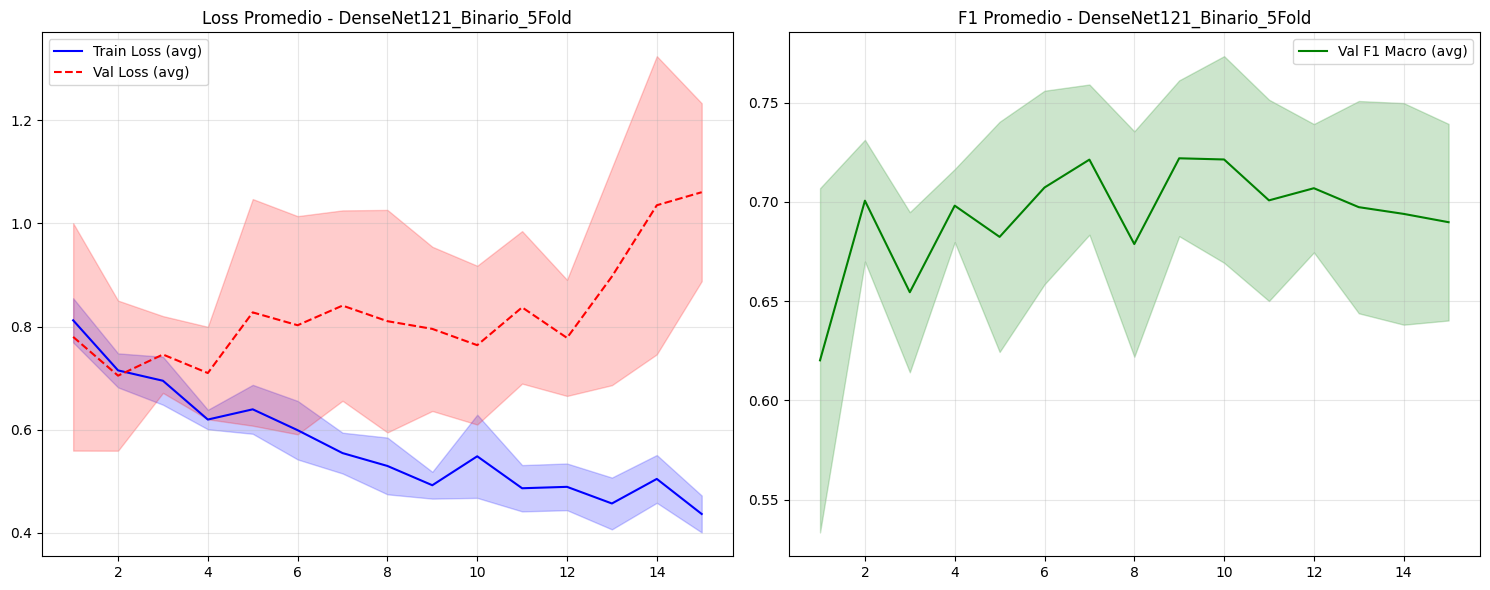


🧪 TEST DETALLADO: MODELOS INDIVIDUALES
  > Evaluando Modelo Fold 1 en Test... F1(Macro)=0.6725
  > Evaluando Modelo Fold 2 en Test... F1(Macro)=0.7571
  > Evaluando Modelo Fold 3 en Test... F1(Macro)=0.6458
  > Evaluando Modelo Fold 4 en Test... F1(Macro)=0.7325
  > Evaluando Modelo Fold 5 en Test... F1(Macro)=0.7079
              f1_macro  accuracy   kappa
Fold_Origen                             
Model_Fold_1    0.6725    0.6732  0.3635
Model_Fold_2    0.7571    0.7582  0.5159
Model_Fold_3    0.6458    0.6471  0.2947
Model_Fold_4    0.7325    0.7386  0.4654
Model_Fold_5    0.7079    0.7124  0.4158

🧩 EVALUACIÓN ENSEMBLE (Promedio de Probabilidades)


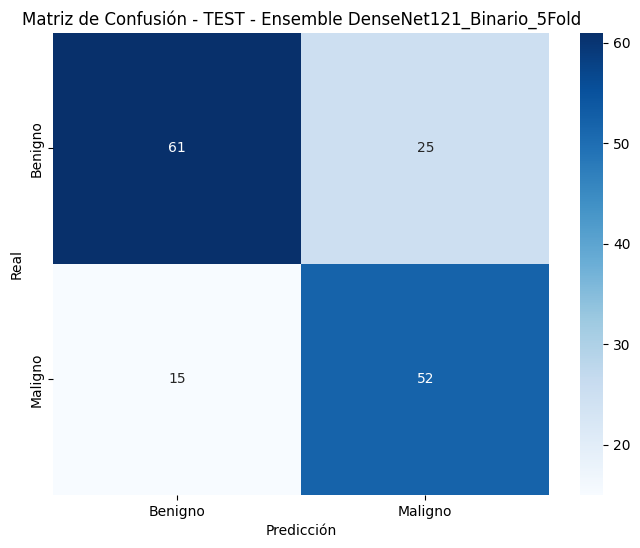


REPORTE: TEST - Ensemble DenseNet121_Binario_5Fold
              precision    recall  f1-score   support

     Benigno       0.80      0.71      0.75        86
     Maligno       0.68      0.78      0.72        67

    accuracy                           0.74       153
   macro avg       0.74      0.74      0.74       153
weighted avg       0.75      0.74      0.74       153

────────────────────────────────────────────────────────────
  Accuracy:           0.7386
  F1 Macro:           0.7377
  Recall Macro:       0.7427
  Cohen's Kappa:      0.4775

💡 CONCLUSIÓN:
   Mejor Individual (Fold 2) F1(Macro): 0.7571
   Ensemble Completo F1(Macro): 0.7377


In [13]:
import torchvision.models as models
import torch.optim as optim
import torch.nn as nn

# --- Definición de la factoría para DenseNet ---
def crear_densenet121(num_classes, device):
    # 1. Cargar pesos pre-entrenados
    weights = models.DenseNet121_Weights.DEFAULT
    model = models.densenet121(weights=weights)

    # 2. Congelar todo el backbone inicialmente
    for param in model.features.parameters():
        param.requires_grad = False

    # 3. Descongelar últimos bloques (Fine-tuning profundo)
    for param in model.features.denseblock4.parameters():
        param.requires_grad = True
        
    for param in model.features.norm5.parameters():
        param.requires_grad = True

    # 4. Nueva cabeza de clasificación binaria
    num_ftrs = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(num_ftrs, num_classes)
    )

    model = model.to(device)

    # 5. Optimizador con Learning Rates diferenciales
    # Capas profundas (features) -> LR bajo (1e-4)
    # Clasificador (cabeza nueva) -> LR alto (1e-3)
    optimizer = optim.AdamW([
        {'params': model.features.denseblock4.parameters(), 'lr': 0.000811},
        {'params': model.features.norm5.parameters(), 'lr': 0.000811},
        {'params': model.classifier.parameters(), 'lr': 0.003550}
    ], weight_decay=0.057279)
    
    return model, optimizer

# --- Lanzar el Experimento 5-Fold ---
# IMPORTANTE: batch_size=16 para DenseNet
resultados_densenet = lanzar_experimento_kfold(
    crear_modelo_fn=crear_densenet121,
    nombre_exp="DenseNet121_Binario_5Fold",
    device=device,
    batch_size=16,  # <--- Batch reducido
    epochs=15
)

## 8. Modelo 5: YOLO26x-cls

YOLO con backbone potente, estado del arte en extracción de features.


🚀 EXPERIMENTO 5-FOLD YOLO: YOLO26x_CV
✅ Directorio de folds detectado: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_BINARIO/folds_5cv

🔹 FOLD 1/5 (Datos: /home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_BINARIO/folds_5cv/fold_1)
New https://pypi.org/project/ultralytics/8.4.9 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.7 🚀 Python-3.11.14 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 4070 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/ML-and-DL-final-project/Datos/images/SPLIT_BINARIO/folds_5cv/fold_1, degrees=0.0, deterministic=

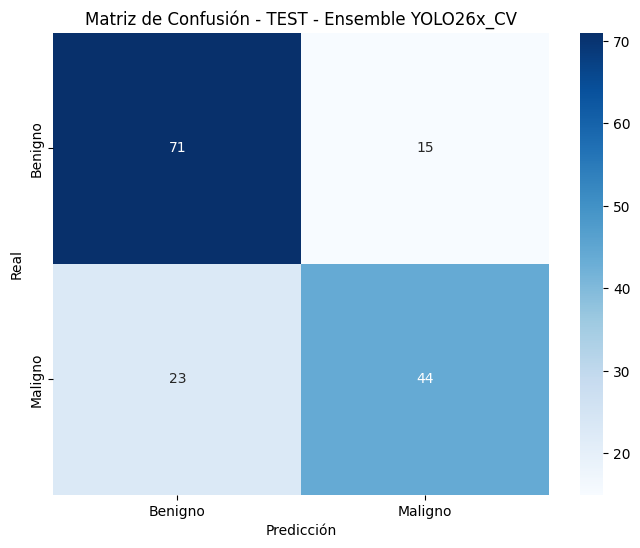


REPORTE: TEST - Ensemble YOLO26x_CV
              precision    recall  f1-score   support

     Benigno       0.76      0.83      0.79        86
     Maligno       0.75      0.66      0.70        67

    accuracy                           0.75       153
   macro avg       0.75      0.74      0.74       153
weighted avg       0.75      0.75      0.75       153

────────────────────────────────────────────────────────────
  Accuracy:           0.7516
  F1 Macro:           0.7437
  Recall Macro:       0.7411
  Cohen's Kappa:      0.4887


In [5]:
import os
import shutil
import gc
import torch
from ultralytics import YOLO

# --- Configuración y Params Optimizados ---
PARAMS_YOLO = {
    'dropout': 0.5,
    'lr0': 0.000819,
    'lrf': 0.061386,
    'momentum': 0.860263,
    'optimizer': 'Adam',
    'weight_decay': 0.000097,
    'imgsz': 224,
    'batch': 16,
    'patience': 5
}

# --- Asegurar Folds Físicos (Necesario para YOLO) ---
FOLDS_DIR = os.path.abspath(f"{RUTA_BASE}/folds_5cv")

def preparar_folds_yolo():
    """Si no existen, crea la estructura física folds_5cv"""
    if os.path.exists(FOLDS_DIR):
        print(f"✅ Directorio de folds detectado: {FOLDS_DIR}")
        return

    print(f"🔨 Creando directorios físicos en {FOLDS_DIR}...")
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(range(len(targets)), targets)):
        fold_name = f"fold_{fold_idx+1}"
        
        # Train
        for i in train_idx:
            src = full_train_dataset.samples[i][0]
            cls = full_train_dataset.classes[targets[i]]
            dst = os.path.join(FOLDS_DIR, fold_name, "train", cls, os.path.basename(src))
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            if not os.path.exists(dst): shutil.copy2(src, dst)
            
        # Val
        for i in val_idx:
            src = full_train_dataset.samples[i][0]
            cls = full_train_dataset.classes[targets[i]]
            dst = os.path.join(FOLDS_DIR, fold_name, "val", cls, os.path.basename(src))
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            if not os.path.exists(dst): shutil.copy2(src, dst)

# --- Funciones de Inferencia Adaptadas a YOLO ---
def predecir_yolo(model, dataset_path, classes):
    y_true, y_pred, y_probs = [], [], []
    for class_idx, class_name in enumerate(classes):
        class_dir = os.path.join(dataset_path, class_name)
        if not os.path.exists(class_dir): continue
        for img_file in os.listdir(class_dir):
            if not img_file.lower().endswith(('.png', '.jpg', '.jpeg')): continue
            img_path = os.path.join(class_dir, img_file)
            
            results = model(img_path, verbose=False)
            res = results[0]
            probs = res.probs.data.cpu().numpy()
            pred = res.probs.top1
            
            y_true.append(class_idx)
            y_pred.append(pred)
            y_probs.append(probs)
    return np.array(y_true), np.array(y_pred), np.array(y_probs)

# --- BUCLE PRINCIPAL YOLO CV ---
def lanzar_yolo_cv(nombre_exp="YOLO26x_CV", epochs=15):
    print(f"\n{'='*70}\n🚀 EXPERIMENTO 5-FOLD YOLO: {nombre_exp}\n{'='*70}")
    
    preparar_folds_yolo()
    classes = full_train_dataset.classes
    metricas_folds = []
    trained_models = [] 
    
    for fold_idx in range(K_FOLDS):
        fold_path = os.path.join(FOLDS_DIR, f"fold_{fold_idx+1}")
        print(f"\n🔹 FOLD {fold_idx+1}/{K_FOLDS} (Datos: {fold_path})")
        
        # 1. Cargar Modelo
        model = YOLO('yolo26x-cls.pt')
        
        # 2. Entrenar
        # Nota: Ultralytics guarda en {project}/{name}
        model.train(
            data=fold_path,
            epochs=epochs,
            project=f"runs/{nombre_exp}",
            name=f"fold_{fold_idx+1}",
            exist_ok=True,
            plots=False,
            **PARAMS_YOLO 
        )
        
        # 3. Validar
        print("   🔎 Evaluando métricas personalizadas en Val...")
        val_path = os.path.join(fold_path, "val")
        yt, yp, _ = predecir_yolo(model, val_path, classes)
        
        mets = calcular_metricas(yt, yp)
        print(f"   🏁 Fin Fold {fold_idx+1}: F1(Macro)={mets['f1_macro']:.4f}")
        metricas_folds.append(mets)
        
        # Ruta correcta del best.pt
        best_pt = f"runs/classify/runs/{nombre_exp}/fold_{fold_idx+1}/weights/best.pt"
        trained_models.append(best_pt)
        
        # --- LIMPIEZA DE MEMORIA ---
        del model
        gc.collect()
        torch.cuda.empty_cache()
        print(f"   🧹 Memoria liberada.")

    # --- RESUMEN CV ---
    print(f"\n{'='*70}\n📊 RESUMEN VALIDACIÓN (CV) - {nombre_exp}\n{'='*70}")
    df = pd.DataFrame(metricas_folds, index=[f"Fold {i+1}" for i in range(K_FOLDS)])
    df.loc['Media'] = df.mean()
    df.loc['Std'] = df.std()
    print(df[['f1_macro', 'accuracy', 'kappa']].round(4).to_string())
    
    # --- ENSEMBLE TEST ---
    print(f"\n{'='*70}\n🧪 TEST ENSEMBLE YOLO\n{'='*70}")
    
    test_path = f"{RUTA_BASE}/test"
    all_probs = []
    
    for i, model_path in enumerate(trained_models):
        print(f"  > Cargando Fold {i+1}: {model_path}")
        m = YOLO(model_path)
        
        _, _, probs = predecir_yolo(m, test_path, classes)
        all_probs.append(probs)
        
        # Limpieza también aquí
        del m
        gc.collect()
        torch.cuda.empty_cache()
        
    avg_probs = np.mean(all_probs, axis=0)
    final_preds = np.argmax(avg_probs, axis=1)
    
    # Ground Truth Test
    y_test_true, _, _ = predecir_yolo(YOLO('yolo26x-cls.pt'), test_path, classes) # Dummy load solo para labels
    
    metrics_ensemble = mostrar_reporte_completo(y_test_true, final_preds, classes, f"TEST - Ensemble {nombre_exp}")
    
    return df, metrics_ensemble

# --- EJECUTAR ---
res_yolo = lanzar_yolo_cv(epochs=15)

## 9. Ensemble: ResNet-50 + DenseNet-121 + YOLO26x


In [17]:
from sklearn.metrics import roc_curve, auc

# --- 1. Cargar los Datos de Test una vez ---
test_loader = get_test_loader(batch_size=16) # Batch conservador
y_true_test = []
for _, y in test_loader: y_true_test.extend(y.numpy())
y_true_test = np.array(y_true_test)

# --- 2. Funciones de Carga Específicas ---

def obtener_probs_pytorch(model_fn, path_weights, device):
    model, _ = model_fn(num_classes=2, device=device)
    model.load_state_dict(torch.load(path_weights))
    _, _, probs = obtener_predicciones(model, test_loader, device)
    return probs # [N, 2]

def obtener_probs_yolo(path_weights, dataset_path, classes):
    from ultralytics import YOLO
    model = YOLO(path_weights)
    _, _, probs = predecir_yolo(model, dataset_path, classes)
    return probs # [N, 2]

# --- 3. Obtener Probabilidades de los "Campeones" ---
print("Cargando ResNet Fold 5...")
probs_resnet = obtener_probs_pytorch(crear_resnet18, "ResNet18_Binario_5Fold_fold5.pth", device)

print("Cargando DenseNet Fold 2...")
probs_densenet = obtener_probs_pytorch(crear_densenet121, "DenseNet121_Binario_5Fold_fold2.pth", device)

print("Cargando YOLO Fold 2...")
# Ajusta la ruta si es diferente, asumo la estándar de tu script anterior
probs_yolo = obtener_probs_yolo("runs/classify/runs/YOLO26x_CV/fold_2/weights/best.pt", f"{RUTA_BASE}/test", classes)



Cargando ResNet Fold 5...
Cargando DenseNet Fold 2...
Cargando YOLO Fold 2...


🔎 GRID SEARCH: PESOS ENSEMBLE BINARIO
Objetivos:
  1️⃣ Maximizar F1-Score Clase Maligno (Prioridad)
  2️⃣ Maximizar F1-Macro
✅ Evaluadas 66 combinaciones.

🏆 GANADORES
🥇 MEJOR F1-MALIGNO: 0.8028
   Pesos: ResNet=0.1 | Dense=0.5 | YOLO=0.4

🥈 MEJOR F1-MACRO: 0.8160
   Pesos: ResNet=0.1 | Dense=0.5 | YOLO=0.4

📊 TOP 10 COMBINACIONES (Ordenado por F1-Maligno)
 w_resnet  w_densenet  w_yolo  f1_maligno  f1_macro    kappa  score_mix
      0.2         0.4     0.4    0.802817  0.816043 0.633094   0.808107
      0.1         0.5     0.4    0.802817  0.816043 0.633094   0.808107
      0.5         0.2     0.3    0.785185  0.807797 0.615611   0.794230
      0.4         0.3     0.3    0.783217  0.796516 0.594442   0.788537
      0.5         0.3     0.2    0.776978  0.795675 0.591789   0.784457
      0.1         0.6     0.3    0.775510  0.783982 0.571064   0.778899
      0.0         0.7     0.3    0.775510  0.783982 0.571064   0.778899
      0.3         0.4     0.3    0.774648  0.789763 0.580678   0.

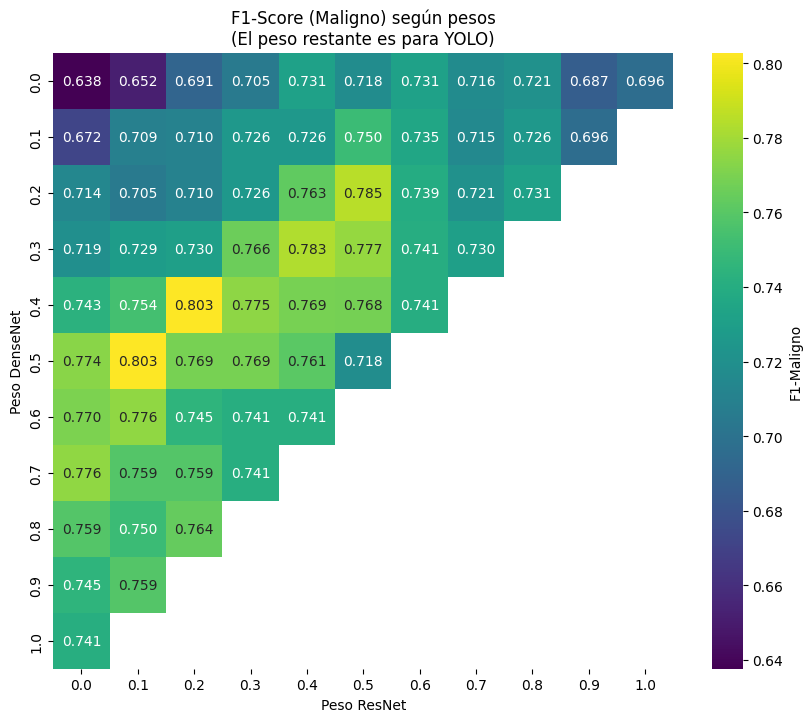

In [18]:
# ============================================================================
# 🔎 BÚSQUEDA DE PESOS ÓPTIMOS (SOFT VOTING) - BINARIO
# ============================================================================
from itertools import product
import pandas as pd
import seaborn as sns
from sklearn.metrics import f1_score, cohen_kappa_score

print(f"{'='*60}\n🔎 GRID SEARCH: PESOS ENSEMBLE BINARIO\n{'='*60}")
print("Objetivos:")
print("  1️⃣ Maximizar F1-Score Clase Maligno (Prioridad)")
print("  2️⃣ Maximizar F1-Macro")
print(f"{'='*60}")

# Rango de pesos (0.0 a 1.0 con paso 0.1)
step = 0.1
weights_range = [round(x * step, 2) for x in range(0, 11)]

results = []
best_maligno = {'score': 0, 'weights': None}
best_macro = {'score': 0, 'weights': None}

count = 0

# Iteramos combinaciones
for w_rn in weights_range:
    for w_dn in weights_range:
        w_yo = round(1.0 - w_rn - w_dn, 2)
        
        # Filtro: suma debe ser 1 y pesos válidos
        if w_yo < 0 or w_yo > 1.0 or abs(w_rn + w_dn + w_yo - 1.0) > 0.01:
            continue
            
        count += 1
        
        # Calcular Probabilidades Ponderadas
        # Asumimos que ya tenemos probs_resnet, probs_densenet, probs_yolo cargados del paso anterior
        probs_ensemble = (w_rn * probs_resnet) + (w_dn * probs_densenet) + (w_yo * probs_yolo)
        preds_ensemble = np.argmax(probs_ensemble, axis=1)
        
        # Calcular Métricas
        f1_m = f1_score(y_true_test, preds_ensemble, pos_label=1, average='binary', zero_division=0)
        f1_mac = f1_score(y_true_test, preds_ensemble, average='macro')
        kappa = cohen_kappa_score(y_true_test, preds_ensemble)
        
        # Guardar
        res = {
            'w_resnet': w_rn,
            'w_densenet': w_dn,
            'w_yolo': w_yo,
            'f1_maligno': f1_m,
            'f1_macro': f1_mac,
            'kappa': kappa,
            'score_mix': (0.6 * f1_m) + (0.4 * f1_mac) # Damos más peso al maligno
        }
        results.append(res)
        
        # Trackear mejores
        if f1_m > best_maligno['score']:
            best_maligno = {'score': f1_m, 'weights': (w_rn, w_dn, w_yo)}
        
        if f1_mac > best_macro['score']:
            best_macro = {'score': f1_mac, 'weights': (w_rn, w_dn, w_yo)}

print(f"✅ Evaluadas {count} combinaciones.")

# ============================================================================
# 🏆 RESULTADOS Y RECOMENDACIÓN
# ============================================================================
df_res = pd.DataFrame(results).sort_values('f1_maligno', ascending=False)

print(f"\n{'='*60}\n🏆 GANADORES\n{'='*60}")
print(f"🥇 MEJOR F1-MALIGNO: {best_maligno['score']:.4f}")
print(f"   Pesos: ResNet={best_maligno['weights'][0]} | Dense={best_maligno['weights'][1]} | YOLO={best_maligno['weights'][2]}")

print(f"\n🥈 MEJOR F1-MACRO: {best_macro['score']:.4f}")
print(f"   Pesos: ResNet={best_macro['weights'][0]} | Dense={best_macro['weights'][1]} | YOLO={best_macro['weights'][2]}")

print(f"\n{'='*60}\n📊 TOP 10 COMBINACIONES (Ordenado por F1-Maligno)\n{'='*60}")
print(df_res.head(10).to_string(index=False))

# ============================================================================
# 📈 HEATMAP (F1-MALIGNO)
# ============================================================================
pivot = df_res.pivot_table(index='w_densenet', columns='w_resnet', values='f1_maligno', aggfunc='max')

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': 'F1-Maligno'})
plt.title('F1-Score (Maligno) según pesos\n(El peso restante es para YOLO)')
plt.xlabel('Peso ResNet')
plt.ylabel('Peso DenseNet')
plt.show()

📊 Usando configuración GANADORA del Grid Search:
   ResNet: 0.1 | DenseNet: 0.5 | YOLO: 0.4

🏆 AUC COMPARATIVO (CLASE MALIGNO)
  > ResNet18 (Fold 5): 0.8008
  > DenseNet121 (Fold 2): 0.8323
  > YOLOv8 (Fold 2): 0.7721
  > Ensemble OPT (0.1/0.5/0.4) 🌟: 0.8771


/home/dmore/code/Máster IA/01.-MASTER COURSES/04.-DEEP LEARNING/dl_env/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


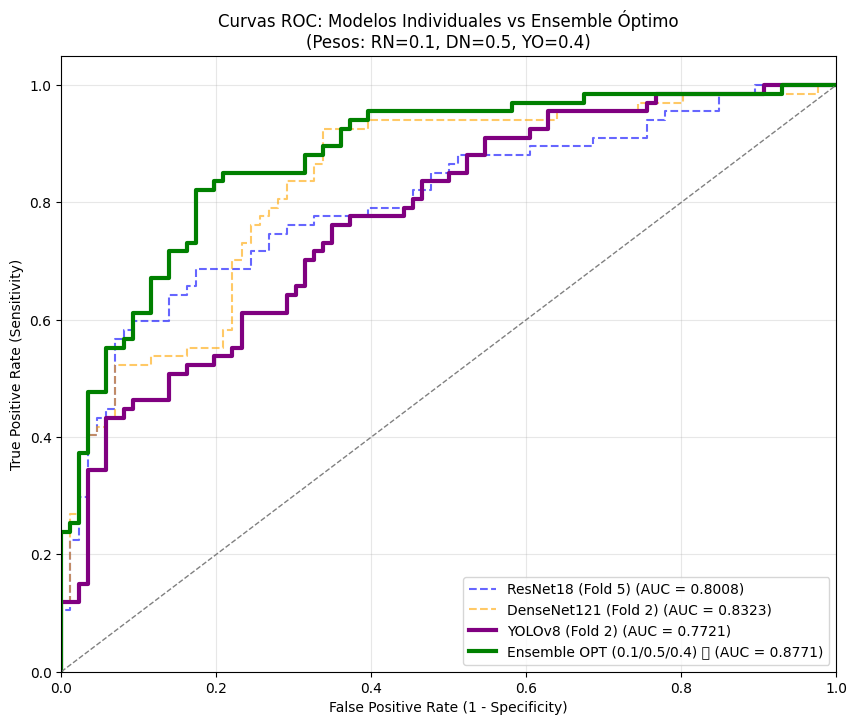

In [19]:
from sklearn.metrics import roc_curve, auc

# --- 1. Recuperar Pesos Óptimos (del paso anterior) ---
# Si por lo que sea no corriste la celda anterior, descomenta y pon los valores a mano:
# best_maligno = {'weights': (0.1, 0.2, 0.7)} 

w_rn, w_dn, w_yo = best_maligno['weights']
print(f"📊 Usando configuración GANADORA del Grid Search:")
print(f"   ResNet: {w_rn} | DenseNet: {w_dn} | YOLO: {w_yo}")

# --- 2. Calcular Ensemble Óptimo (Los 3 modelos) ---
# Asumimos que probs_resnet, probs_densenet, probs_yolo ya están cargados en memoria
probs_ensemble_opt = (w_rn * probs_resnet) + (w_dn * probs_densenet) + (w_yo * probs_yolo)

# --- 3. Graficar Comparativa Final ---
plt.figure(figsize=(10, 8))

models_dict = {
    'ResNet18 (Fold 5)': probs_resnet[:, 1],
    'DenseNet121 (Fold 2)': probs_densenet[:, 1],
    'YOLOv8 (Fold 2)': probs_yolo[:, 1],
    f'Ensemble OPT ({w_rn}/{w_dn}/{w_yo}) 🌟': probs_ensemble_opt[:, 1]
}

colors = ['blue', 'orange', 'purple', 'green']

print(f"\n{'='*50}\n🏆 AUC COMPARATIVO (CLASE MALIGNO)\n{'='*50}")

for (name, scores), color in zip(models_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_true_test, scores, pos_label=1)
    roc_auc = auc(fpr, tpr)
    
    # Destacar el Ensemble y el mejor individual
    is_highlight = 'Ensemble' in name or 'YOLO' in name
    lw = 3 if is_highlight else 1.5
    ls = '-' if is_highlight else '--'
    alpha = 1.0 if is_highlight else 0.6
    
    plt.plot(fpr, tpr, color=color, lw=lw, linestyle=ls, alpha=alpha,
             label=f'{name} (AUC = {roc_auc:.4f})')
    
    print(f"  > {name}: {roc_auc:.4f}")

plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title(f'Curvas ROC: Modelos Individuales vs Ensemble Óptimo\n(Pesos: RN={w_rn}, DN={w_dn}, YO={w_yo})')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()